# Synthetic Mobility Data — Figures & Tables

**Dedicated figure/table notebook.** This notebook *consumes* the artefacts written by
`02_evaluate` and does **no metric recomputation**:

- `outputs/eval_log_v4.json` — per-seed utility + record-level privacy metrics
- `artifacts_v4/<model>/<model>_seed<seed>__mia_results.csv` — per-user MIA scores (for ROC + pooled CIs)
- `artifacts_v4/splits/user_summary_seed<seed>.csv` — activity-group fallback merge

It rebuilds the lightweight aggregations (mean ± std over seeds; user-level bootstrap CIs)
needed to draw figures, then writes a trimmed, thesis-ready figure set and LaTeX/CSV tables.

**Figure plan** (≈6 figures, the rest in tables):
- **RQ1** — Fig 1 grouped dot plot (JS-distance family) · Fig 2 TSTR bar
- **RQ2** — ROC · MIA AUC dot+CI
- **RQ3** — MIA AUC by activity group · near-copy by activity group (stacked)
- **Discussion** — OD-flow JS × MIA AUC trade-off


## 0 · Colab setup
Mount Drive and `cd` to the project root. Comment these out if running locally.

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Not on Colab (or already mounted):', e)

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/UPF_Thesis/v4

/content/drive/MyDrive/UPF_Thesis/v4


## 1 · Config & plotting style
All shared settings live here. `new_fig()` applies a standard size that any
single figure can override with `size=` or an explicit `figsize=`.

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, balanced_accuracy_score

try:
    from IPython.display import display
except ImportError:
    display = print

In [ ]:
# ---- experiment config ----
SEEDS  = [111, 222, 333, 444, 555]
MODELS = ['VAE', 'WGAN_GP', 'Bootstrap']           # Bootstrap = copy-based control
# stored activity-group labels (keys) -> display labels used in every figure/table (values).
# Edit the KEYS to match the strings actually stored in your artefacts.
GROUP_RELABEL = {'10-20': 'Low (10\u201320)', '21-63': 'Medium (21\u201363)', '64+': 'High (64+)'}
GROUP_ORDER   = list(GROUP_RELABEL.values())       # display order

ARTIFACT_ROOT = Path('artifacts_v4')
SPLIT_DIR     = ARTIFACT_ROOT / 'splits'
EVAL_LOG      = 'outputs/eval_log_v4.json'

FIG_DIR = Path('outputs/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR = Path('outputs/tables');  TAB_DIR.mkdir(parents=True, exist_ok=True)

COLOURS = {'Bootstrap': '#d62728', 'VAE': '#1f77b4', 'WGAN_GP': '#2ca02c'}
MODEL_LABELS = {'VAE': 'VAE', 'WGAN_GP': 'WGAN-GP', 'Bootstrap': 'Bootstrap'}
def mlabel(m): return MODEL_LABELS.get(m, m.replace('_', '-'))

FPR_TARGETS = (0.01, 0.05, 0.10)
N_BOOT      = 2000

In [ ]:
# ---- standardised plotting style (overridable per figure) ----
FONT_FAMILY   = 'DejaVu Sans'   # swap to 'serif' to match a serif LaTeX body
BASE_FONTSIZE = 11

mpl.rcParams.update({
    'figure.dpi':        110,
    'savefig.dpi':       200,
    'savefig.bbox':      'tight',
    'font.family':       FONT_FAMILY,
    'font.size':         BASE_FONTSIZE,
    'axes.titlesize':    BASE_FONTSIZE + 1,
    'axes.labelsize':    BASE_FONTSIZE,
    'xtick.labelsize':   BASE_FONTSIZE - 1,
    'ytick.labelsize':   BASE_FONTSIZE - 1,
    'legend.fontsize':   BASE_FONTSIZE - 1,
    'legend.frameon':    False,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'axes.grid.axis':    'y',      # horizontal gridlines only
    'axes.axisbelow':    True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.6,
    'errorbar.capsize':  4,
    'lines.markersize':  8,
    'svg.fonttype':      'none',   # keep SVG text editable / LaTeX-matchable
})

# standard sizes — pass size='wide' etc., or figsize=(w, h) to override
FIGSIZE = {'single': (6.0, 4.2), 'wide': (9.0, 4.2),
           'square': (5.6, 5.2), 'tall': (7.2, 6.0)}

def new_fig(size='single', figsize=None, **kw):
    '''fig, ax(es) at a standard size. Override with size= or figsize=.'''
    fs = figsize if figsize is not None else FIGSIZE.get(size, FIGSIZE['single'])
    return plt.subplots(figsize=fs, **kw)

def save_fig(fig, name, formats=('pdf',)):
    for ext in formats:
        fig.savefig(FIG_DIR / f'{name}.{ext}')
    print('saved:', ', '.join(f'{name}.{e}' for e in formats), '->', FIG_DIR)

In [ ]:
# ---- table export: CSV + LaTeX (booktabs) ----
_LATEX_MAP = {'\u00b1': r'$\pm$', '%': r'\%', '\u2020': r'$\dagger$',
              '\u2021': r'$\ddagger$', '\u2013': '--', '\u2014': '---',
              '\u00d7': r'$\times$'}

def _latexify(x):
    s = str(x)
    for k, v in _LATEX_MAP.items():
        s = s.replace(k, v)
    return s

def export_table(df, name, caption='', label='', index=True):
    '''Save <name>.csv and <name>.tex (booktabs) to TAB_DIR; return df.'''
    df.to_csv(TAB_DIR / f'{name}.csv')
    ldf = df.copy()
    try:
        ldf = ldf.map(_latexify)            # pandas >= 2.1
    except AttributeError:
        ldf = ldf.applymap(_latexify)       # older pandas
    ldf.columns = [_latexify(c) for c in ldf.columns]
    if isinstance(ldf.index, pd.MultiIndex):
        ldf.index = pd.MultiIndex.from_tuples(
            [tuple(_latexify(v) for v in t) for t in ldf.index], names=ldf.index.names)
    else:
        ldf.index = [_latexify(v) for v in ldf.index]
    try:
        body = ldf.to_latex(index=index, escape=False)
    except TypeError:
        body = ldf.to_latex(index=index)
    tex = ('\\begin{table}[ht]\n\\centering\n'
           f'{body}'
           f'\\caption{{{caption}}}\n\\label{{{label}}}\n\\end{{table}}\n')
    (TAB_DIR / f'{name}.tex').write_text(tex)
    print(f'wrote {name}.csv and {name}.tex  (LaTeX: \\usepackage{{booktabs}})')
    return df

## 2 · Load persisted artefacts (no metric recomputation)

In [ ]:
def load_eval_log(path=EVAL_LOG):
    rows = []
    for r in json.loads(Path(path).read_text()):
        flat = {'model': r['model'].replace('__eval', ''), 'seed': r['seed']}
        flat.update({k: v for k, v in r.get('metrics', {}).items() if k != 'by_activity_group'})
        rows.append(flat)
    return pd.DataFrame(rows)


def load_pooled_mia():
    # Concatenate per-user MIA tables across seeds/models; backfill activity_group
    # from user_summary if a table lacks it.
    frames = []
    for model in MODELS:
        for seed in SEEDS:
            f = ARTIFACT_ROOT / model / f'{model.lower()}_seed{seed}__mia_results.csv'
            if not f.exists():
                print(f'  [skip] {f} missing'); continue
            d = pd.read_csv(f)
            d['model'], d['seed'] = model, seed
            if 'activity_group' not in d.columns:
                us = pd.read_csv(SPLIT_DIR / f'user_summary_seed{seed}.csv')
                d = d.merge(us[['user_id', 'activity_group']], on='user_id', how='left')
            frames.append(d)
    if not frames:
        raise FileNotFoundError('No __mia_results.csv found under ' + str(ARTIFACT_ROOT))
    pooled = pd.concat(frames, ignore_index=True)
    miss = {'user_id', 'ground_truth', 'membership_probability'} - set(pooled.columns)
    if miss:
        raise KeyError(f'mia_results missing columns: {miss}')
    if 'activity_group' in pooled and pooled['activity_group'].isna().any():
        print('  [warn] some users lack an activity_group after merge')
    pooled['activity_group'] = (pooled['activity_group'].astype(str)
                                .str.replace('\u2013', '-', regex=False).str.strip())
    return pooled


eval_df = load_eval_log()
pooled  = load_pooled_mia()
print('eval_df:', eval_df.shape, '| models:', sorted(eval_df['model'].unique()))
print('pooled :', len(pooled), 'rows |', pooled['user_id'].nunique(), 'unique users')

eval_df: (15, 35) | models: ['Bootstrap', 'VAE', 'WGAN_GP']
pooled : 795 rows | 85 unique users


## 3 · Aggregations (mean ± std; user-level bootstrap CIs)

In [ ]:
def _mia_metrics(y, p, fpr_targets=FPR_TARGETS):
    out = {'auc': float(roc_auc_score(y, p))}
    fpr, tpr, _ = roc_curve(y, p)
    out['yeom_adv'] = float(np.max(tpr - fpr))
    for t in fpr_targets:
        out[f'tpr@{int(t * 100)}'] = float(np.interp(t, fpr, tpr))
    out['bal_acc'] = float(balanced_accuracy_score(y, (p >= 0.5).astype(int)))
    return out


def cluster_bootstrap(d, n_boot=N_BOOT, seed=0):
    # Resample USERS (clusters), keep all their seed-rows.
    y = d['ground_truth'].to_numpy(); p = d['membership_probability'].to_numpy()
    users = d['user_id'].to_numpy()
    point = _mia_metrics(y, p)
    u2i = {u: np.where(users == u)[0] for u in np.unique(users)}
    uniq = np.array(list(u2i)); rng = np.random.default_rng(seed)
    boots = {k: [] for k in point}
    for _ in range(n_boot):
        idx = np.concatenate([u2i[u] for u in rng.choice(uniq, size=len(uniq), replace=True)])
        yy, pp = y[idx], p[idx]
        if len(np.unique(yy)) < 2:
            continue
        for k, v in _mia_metrics(yy, pp).items():
            boots[k].append(v)
    ci = {k: (float(np.percentile(b, 2.5)), float(np.percentile(b, 97.5)))
          for k, b in boots.items() if b}
    return point, ci


def fmt(pt, ci, k):
    lo, hi = ci.get(k, (np.nan, np.nan))
    return f'{pt[k]:.3f} [{lo:.3f}, {hi:.3f}]'


# ---- per-activity-group record metrics from EVAL_LOG ----
rows = []
for r in json.loads(Path(EVAL_LOG).read_text()):
    model = r['model'].replace('__eval', '')
    for g, vals in r['metrics'].get('by_activity_group', {}).items():
        rows.append({'model': model, 'seed': r['seed'],
                     'group': str(g).replace('\u2013', '-').strip(), **vals})
group_eval = pd.DataFrame(rows)

# ---- apply display relabel (keys must match the STORED labels; unmapped values kept) ----
pooled['activity_group'] = pooled['activity_group'].map(GROUP_RELABEL).fillna(pooled['activity_group'])
group_eval['group']      = group_eval['group'].map(GROUP_RELABEL).fillna(group_eval['group'])

# ---- pooled MIA bootstrap: overall and per activity group ----
mia_boot = {mdl: cluster_bootstrap(pooled[pooled['model'] == mdl], seed=1000 + i)
            for i, mdl in enumerate(MODELS)}

mia_boot_by_group = {}
for i, mdl in enumerate(MODELS):
    for j, grp in enumerate(GROUP_ORDER):
        d = pooled[(pooled['model'] == mdl) & (pooled['activity_group'] == grp)]
        if d.empty or d['ground_truth'].nunique() < 2:
            continue
        mia_boot_by_group[(mdl, grp)] = cluster_bootstrap(d, seed=2000 + i * 10 + j)

print('bootstrap done:', len(mia_boot), 'models,', len(mia_boot_by_group), 'model x group cells')
print('control check — Bootstrap MIA AUC =', round(mia_boot['Bootstrap'][0]['auc'], 3),
      '(expect ~0.76)')

bootstrap done: 3 models, 9 model x group cells
control check — Bootstrap MIA AUC = 0.75 (expect ~0.76)


## 4 · Tables (CI / std) → CSV + LaTeX
Full metric sets live here; figures stay lean.

In [ ]:
eval_df.columns

Index(['model', 'seed', 'od_flow_jsd', 'od_flow_js_distance',
       'od_flow_coverage', 'n_real_od_pairs', 'n_synth_od_pairs',
       'origin_cell_js_distance', 'origin_cell_coverage',
       'dest_cell_js_distance', 'dest_cell_coverage', 'hour_js_distance',
       'dow_js_distance', 'corr_mean_abs_diff', 'corr_frobenius',
       'tstr_macro_f1', 'trtr_macro_f1', 'tstr_ratio', 'mean_ks',
       'mean_wasserstein_std', 'mean_std_ratio', 'near_copy_rate',
       'exact_match_rate', 'dcr_train_median', 'dcr_train_p5',
       'dcr_holdout_median', 'dcr_ratio_train_over_holdout', 'nndr_median',
       'nndr_p5', 'mia_accuracy', 'mia_f1', 'mia_auc', 'mia_tpr_at_fpr_1',
       'mia_tpr_at_fpr_5', 'mia_tpr_at_fpr_10'],
      dtype='object')

In [ ]:
eval_df

,model,seed,od_flow_jsd,od_flow_js_distance,od_flow_coverage,n_real_od_pairs,n_synth_od_pairs,origin_cell_js_distance,origin_cell_coverage,dest_cell_js_distance,...,dcr_holdout_median,dcr_ratio_train_over_holdout,nndr_median,nndr_p5,mia_accuracy,mia_f1,mia_auc,mia_tpr_at_fpr_1,mia_tpr_at_fpr_5,mia_tpr_at_fpr_10
0,VAE,111,0.421617,0.649320,0.431476,1328,1966,0.841315,0.386139,0.851235,...,4.438231e-02,0.771054,1.000000,6.576684e-01,0.566038,0.646154,0.506349,0.028571,0.028571,0.057143
1,WGAN_GP,111,0.375003,0.612375,0.383283,1328,1886,0.839753,0.405941,0.840862,...,3.926260e-02,0.845770,1.000000,7.143320e-01,0.509434,0.617647,0.455556,0.005143,0.025714,0.028571
2,Bootstrap,111,0.061459,0.247909,0.717620,1328,953,0.103037,0.816832,0.108873,...,3.274458e-09,0.757115,0.999551,9.493161e-08,0.754717,0.843373,0.545238,0.005143,0.025714,0.051429
3,VAE,222,0.459951,0.678197,0.417169,1328,1708,0.856308,0.356436,0.848587,...,4.084320e-02,0.857105,1.000000,6.348920e-01,0.566038,0.676056,0.518254,0.000000,0.000000,0.200000
4,WGAN_GP,222,0.444661,0.666829,0.350904,1328,1575,0.853723,0.346535,0.854854,...,3.822273e-02,0.888693,1.000000,6.952694e-01,0.603774,0.720000,0.576984,0.028571,0.028571,0.028571
5,Bootstrap,222,0.127969,0.357728,0.618976,1328,822,0.216697,0.658416,0.212121,...,3.601173e-09,0.844746,0.999630,8.986591e-08,0.830189,0.886076,0.778571,0.015429,0.077143,0.297143
6,VAE,333,0.434861,0.659440,0.447289,1328,2024,0.847799,0.420792,0.849464,...,4.379840e-02,0.797586,1.000000,6.345355e-01,0.622642,0.756098,0.469048,0.062286,0.082857,0.085714
7,WGAN_GP,333,0.398633,0.631374,0.378765,1328,1878,0.841652,0.386139,0.837136,...,3.926796e-02,0.840717,1.000000,6.792390e-01,0.547170,0.700000,0.418254,0.038857,0.080000,0.085714
8,Bootstrap,333,0.069762,0.264124,0.713102,1328,947,0.109590,0.826733,0.118287,...,3.647956e-09,0.790374,0.999524,1.089201e-07,0.754717,0.843373,0.739683,0.010286,0.051429,0.320000
9,VAE,444,0.428854,0.654869,0.436747,1328,1867,0.853651,0.366337,0.848227,...,4.053574e-02,0.844476,1.000000,6.615840e-01,0.584906,0.676471,0.558730,0.028571,0.028571,0.028571


In [ ]:
# ---- RQ1 utility table (mean +/- std over seeds) ----
RQ1_METRICS = {
    'origin_cell_js_distance': 'Origin JS Distance',
    'dest_cell_js_distance': 'Destination JS Distance',
    'od_flow_js_distance':   'OD-flow JS Distance',
    'od_flow_coverage':      'OD-flow Coverage',
    'hour_js_distance':     'Hour-of-day JS Distance',
    'dow_js_distance':      'Day-of-week JS Distance',
    'corr_mean_abs_diff':    'Correlation Difference',
    'mean_wasserstein_std':  'Wasserstein Distance',
    'mean_std_ratio':        'Spread Ratio',
    'mean_ks':               'Kolmogorov-Smirnov Distance',
    'tstr_ratio':            'Forecast Task (TSTR)',
}
rows = []
for mdl in MODELS:
    sub = eval_df[eval_df['model'] == mdl]
    row = {'Model': mlabel(mdl)}
    for col, label in RQ1_METRICS.items():
        row[label] = (f'{sub[col].mean():.3f} \u00b1 {sub[col].std():.3f}'
                      if col in eval_df.columns else 'N/A')
    rows.append(row)
rq1_tbl = pd.DataFrame(rows).set_index('Model').T
#print('RQ1 utility — mean \u00b1 std over seeds  (\u2020 fragile on discretised marginals \u2192 Limitations)')
display(rq1_tbl)
export_table(rq1_tbl, 'rq1_utility',
             caption='RQ1 Utility Metrics (mean $\\pm$ standard deviation over five seed runs). JS Distance denotes the Jensen-Shannon distance between the corresponding real and synthetic marginal distributions. Mean Wasserstein Distance is computed on features standardised using statistics from the real data',
             label='tab:rq1_utility')

Model,VAE,WGAN-GP,Bootstrap
Origin JS Distance,0.852 ± 0.007,0.846 ± 0.008,0.154 ± 0.068
Destination JS Distance,0.851 ± 0.003,0.843 ± 0.009,0.159 ± 0.066
OD-flow JS Distance,0.672 ± 0.027,0.637 ± 0.035,0.308 ± 0.077
OD-flow Coverage,0.427 ± 0.018,0.372 ± 0.013,0.673 ± 0.050
Hour-of-day JS Distance,0.154 ± 0.021,0.149 ± 0.023,0.058 ± 0.024
Day-of-week JS Distance,0.116 ± 0.010,0.117 ± 0.014,0.013 ± 0.006
Correlation Difference,0.071 ± 0.013,0.052 ± 0.019,0.030 ± 0.010
Wasserstein Distance,0.167 ± 0.002,0.120 ± 0.005,0.018 ± 0.004
Spread Ratio,0.804 ± 0.011,0.908 ± 0.024,1.007 ± 0.012
Kolmogorov-Smirnov Distance,0.166 ± 0.012,0.157 ± 0.014,0.219 ± 0.017


wrote rq1_utility.csv and rq1_utility.tex  (LaTeX: \usepackage{booktabs})


Model,VAE,WGAN-GP,Bootstrap
Origin JS Distance,0.852 ± 0.007,0.846 ± 0.008,0.154 ± 0.068
Destination JS Distance,0.851 ± 0.003,0.843 ± 0.009,0.159 ± 0.066
OD-flow JS Distance,0.672 ± 0.027,0.637 ± 0.035,0.308 ± 0.077
OD-flow Coverage,0.427 ± 0.018,0.372 ± 0.013,0.673 ± 0.050
Hour-of-day JS Distance,0.154 ± 0.021,0.149 ± 0.023,0.058 ± 0.024
Day-of-week JS Distance,0.116 ± 0.010,0.117 ± 0.014,0.013 ± 0.006
Correlation Difference,0.071 ± 0.013,0.052 ± 0.019,0.030 ± 0.010
Wasserstein Distance,0.167 ± 0.002,0.120 ± 0.005,0.018 ± 0.004
Spread Ratio,0.804 ± 0.011,0.908 ± 0.024,1.007 ± 0.012
Kolmogorov-Smirnov Distance,0.166 ± 0.012,0.157 ± 0.014,0.219 ± 0.017


In [ ]:
# ---- RQ2 privacy table (MIA point [95% CI] + record-level mean +/- std) ----
rec_keys = [k for k in ['near_copy_rate']#, 'exact_match_rate','dcr_ratio_train_over_holdout', 'nndr_median']
            if k in eval_df.columns]
rec_stats = eval_df.groupby('model')[rec_keys].agg(['mean', 'std'])
rec_label = {'near_copy_rate': 'Near-copy Rate'}#, 'exact_match_rate': 'exact-match',
             #'dcr_ratio_train_over_holdout': 'DCR ratio \u2020', 'nndr_median': 'NNDR median \u2020'}

rows = []
for mdl in MODELS:
    pt, ci = mia_boot[mdl]
    d = pooled[pooled['model'] == mdl]
    row = {'Model': mlabel(mdl),
           'Users Evaluated': d['user_id'].nunique(),
          #'Accuracy': fmt(pt, ci, 'mia_accuracy'),
          'Balanced Accuracy': fmt(pt, ci, 'bal_acc'),
           #'F1': fmt(pt, ci, 'mia_f1'),
           'AUC':  fmt(pt, ci, 'auc'),
           'Maximum Advantage': fmt(pt, ci, 'yeom_adv'),
           'TPR @10% FPR':  fmt(pt, ci, 'tpr@10'),
           'TPR @5% FPR': fmt(pt, ci, 'tpr@5'), #\u2021
           'TPR @1% FPR': fmt(pt, ci, 'tpr@1'), #\u2021
           }
    for k in rec_keys:
        mu, sd = rec_stats.loc[mdl, (k, 'mean')], rec_stats.loc[mdl, (k, 'std')]
        row[rec_label[k]] = f'{mu:.3f} \u00b1 {sd:.3f}'
    rows.append(row)
rq2_tbl = pd.DataFrame(rows).set_index('Model')
print('RQ2 privacy — MIA: point [95% cluster-bootstrap Confidence]; Near-copy Rate: mean \u00b1 std over seeds')
print('  \u2020 degenerate on discretised coords (Limitations)   \u2021 below ~90 out-user resolution')
display(rq2_tbl)
export_table(rq2_tbl.T, 'rq2_privacy',
             caption='RQ2 Privacy Metrics. MIA-associated metrics are pooled across seed runs and reported with 95\\% cluster-bootstrap confidence intervals. Users Evaluated denotes the number of distinct users contributing to each pooled estimate. Near-copy Rate is reported as mean $\\pm$ standard deviation over seed runs.',
             label='tab:rq2_privacy')

RQ2 privacy — MIA: point [95% cluster-bootstrap Confidence]; Near-copy Rate: mean ± std over seeds
  † degenerate on discretised coords (Limitations)   ‡ below ~90 out-user resolution


,Users Evaluated,Balanced Accuracy,AUC,Maximum Advantage,TPR @10% FPR,TPR @5% FPR,TPR @1% FPR,Near-copy Rate
Model,,,,,,,,
VAE,85,"0.515 [0.460, 0.571]","0.497 [0.433, 0.567]","0.050 [0.032, 0.177]","0.114 [0.062, 0.194]","0.069 [0.039, 0.135]","0.000 [0.000, 0.087]",0.009 ± 0.001
WGAN-GP,85,"0.474 [0.417, 0.529]","0.503 [0.432, 0.575]","0.070 [0.020, 0.206]","0.103 [0.038, 0.184]","0.059 [0.023, 0.116]","0.030 [0.010, 0.070]",0.010 ± 0.002
Bootstrap,85,"0.692 [0.629, 0.757]","0.750 [0.673, 0.823]","0.446 [0.350, 0.577]","0.187 [0.078, 0.386]","0.081 [0.018, 0.237]","0.013 [0.002, 0.074]",1.000 ± 0.000


wrote rq2_privacy.csv and rq2_privacy.tex  (LaTeX: \usepackage{booktabs})


Model,VAE,WGAN-GP,Bootstrap
Users Evaluated,85,85,85
Balanced Accuracy,"0.515 [0.460, 0.571]","0.474 [0.417, 0.529]","0.692 [0.629, 0.757]"
AUC,"0.497 [0.433, 0.567]","0.503 [0.432, 0.575]","0.750 [0.673, 0.823]"
Maximum Advantage,"0.050 [0.032, 0.177]","0.070 [0.020, 0.206]","0.446 [0.350, 0.577]"
TPR @10% FPR,"0.114 [0.062, 0.194]","0.103 [0.038, 0.184]","0.187 [0.078, 0.386]"
TPR @5% FPR,"0.069 [0.039, 0.135]","0.059 [0.023, 0.116]","0.081 [0.018, 0.237]"
TPR @1% FPR,"0.000 [0.000, 0.087]","0.030 [0.010, 0.070]","0.013 [0.002, 0.074]"
Near-copy Rate,0.009 ± 0.001,0.010 ± 0.002,1.000 ± 0.000


In [ ]:
rq2_tbl.T

Model,VAE,WGAN-GP,Bootstrap
Users Evaluated,85,85,85
Balanced Accuracy,"0.515 [0.460, 0.571]","0.474 [0.417, 0.529]","0.692 [0.629, 0.757]"
AUC,"0.497 [0.433, 0.567]","0.503 [0.432, 0.575]","0.750 [0.673, 0.823]"
Maximum Advantage,"0.050 [0.032, 0.177]","0.070 [0.020, 0.206]","0.446 [0.350, 0.577]"
TPR @10% FPR,"0.114 [0.062, 0.194]","0.103 [0.038, 0.184]","0.187 [0.078, 0.386]"
TPR @5% FPR,"0.069 [0.039, 0.135]","0.059 [0.023, 0.116]","0.081 [0.018, 0.237]"
TPR @1% FPR,"0.000 [0.000, 0.087]","0.030 [0.010, 0.070]","0.013 [0.002, 0.074]"
Near-copy Rate,0.009 ± 0.001,0.010 ± 0.002,1.000 ± 0.000


In [ ]:
# ---- RQ3 privacy by activity group ----
rec_keys_g = [k for k in ['priv_near_copy_rate']#, 'priv_exact_match_rate','priv_dcr_ratio_train_over_holdout', 'priv_nndr_median']
              if k in group_eval.columns]
rec_stats_g = group_eval.groupby(['model', 'group'])[rec_keys_g].agg(['mean', 'std'])
rec_label_g = {'priv_near_copy_rate': 'Near-copy Rate', 'priv_exact_match_rate': 'exact-match',
               'priv_dcr_ratio_train_over_holdout': 'DCR ratio \u2020',
               'priv_nndr_median': 'NNDR median \u2020'}

rows = []
for mdl in MODELS:
    for grp in GROUP_ORDER:
        row = {'model': mlabel(mdl), 'activity_group': grp}
        if (mdl, grp) in mia_boot_by_group:
            pt, ci = mia_boot_by_group[(mdl, grp)]
            d = pooled[(pooled['model'] == mdl) & (pooled['activity_group'] == grp)]
            row.update({'Users': d['user_id'].nunique(),
                        #'Balanced Accuracy': fmt(pt, ci, 'bal_acc'),
                        'AUC':  fmt(pt, ci, 'auc'),
                        #'Maximum Advantage': fmt(pt, ci, 'yeom_adv'),
                        'TPR @ 10% FPR':  fmt(pt, ci, 'tpr@10')})
        else:
            row.update({'n_users': 0, 'MIA AUC': 'N/A', 'Yeom adv': 'N/A',
                        'Bal. acc': 'N/A', 'TPR@10%': 'N/A'})
        for k in rec_keys_g:
            if (mdl, grp) in rec_stats_g.index:
                mu = rec_stats_g.loc[(mdl, grp), (k, 'mean')]
                sd = rec_stats_g.loc[(mdl, grp), (k, 'std')]
                row[rec_label_g[k]] = f'{mu:.3f} \u00b1 {sd:.3f}'
            else:
                row[rec_label_g[k]] = 'N/A'
        rows.append(row)

rq3_tbl = (pd.DataFrame(rows).set_index(['model', 'activity_group'])
           .reindex(pd.MultiIndex.from_product([[mlabel(m) for m in MODELS], GROUP_ORDER],
                                               names=['Model', 'Activity Group'])))

rq3_export = rq3_tbl.reset_index()


print('RQ3 privacy by activity group — MIA: point [95% CI]; record-level: mean \u00b1 std')
display(rq3_tbl)
export_table(rq3_export, 'rq3_by_activity',
             caption='RQ3 Privacy by Activity Group. MIA-associated metrics are pooled within each activity group and reported with 95\\% cluster-bootstrap confidence intervals. Users denotes the number of distinct users contributing to each pooled estimate. Near-copy Rate is reported as mean $\\pm$ standard deviation over seed runs.',
             label='tab:rq3_by_activity',
             index=False)

RQ3 privacy by activity group — MIA: point [95% CI]; record-level: mean ± std


Users                   AUC         TPR @ 10% FPR  \
Model     Activity Group                                                      
VAE       Low (10–20)        28  0.580 [0.440, 0.716]  0.186 [0.057, 0.379]   
          Medium (21–63)     29  0.530 [0.460, 0.610]  0.263 [0.113, 0.362]   
          High (64+)         28  0.392 [0.273, 0.517]  0.102 [0.000, 0.193]   
WGAN-GP   Low (10–20)        28  0.578 [0.468, 0.692]  0.220 [0.024, 0.400]   
          Medium (21–63)     29  0.490 [0.382, 0.598]  0.193 [0.029, 0.327]   
          High (64+)         28  0.460 [0.320, 0.612]  0.068 [0.016, 0.196]   
Bootstrap Low (10–20)        28  0.729 [0.618, 0.858]  0.237 [0.019, 0.586]   
          Medium (21–63)     29  0.770 [0.652, 0.874]  0.316 [0.036, 0.569]   
          High (64+)         28  0.746 [0.582, 0.895]  0.237 [0.038, 0.623]   

                         Near-copy Rate  
Model     Activity Group                 
VAE       Low (10–20)     0.004 ± 0.001  
          Medium (21–63)  0.005 ± 0.001  
          High (64+)      0.008 ± 0.001  
WGAN-GP   Low (10–20)     0.006 ± 0.002  
          Medium (21–63)  0.007 ± 0.002  
          High (64+)      0.010 ± 0.002  
Bootstrap Low (10–20)     0.483 ± 0.040  
          Medium (21–63)  0.613 ± 0.011  
          High (64+)      0.935 ± 0.025

wrote rq3_by_activity.csv and rq3_by_activity.tex  (LaTeX: \usepackage{booktabs})


,Model,Activity Group,Users,AUC,TPR @ 10% FPR,Near-copy Rate
0,VAE,Low (10–20),28,"0.580 [0.440, 0.716]","0.186 [0.057, 0.379]",0.004 ± 0.001
1,VAE,Medium (21–63),29,"0.530 [0.460, 0.610]","0.263 [0.113, 0.362]",0.005 ± 0.001
2,VAE,High (64+),28,"0.392 [0.273, 0.517]","0.102 [0.000, 0.193]",0.008 ± 0.001
3,WGAN-GP,Low (10–20),28,"0.578 [0.468, 0.692]","0.220 [0.024, 0.400]",0.006 ± 0.002
4,WGAN-GP,Medium (21–63),29,"0.490 [0.382, 0.598]","0.193 [0.029, 0.327]",0.007 ± 0.002
5,WGAN-GP,High (64+),28,"0.460 [0.320, 0.612]","0.068 [0.016, 0.196]",0.010 ± 0.002
6,Bootstrap,Low (10–20),28,"0.729 [0.618, 0.858]","0.237 [0.019, 0.586]",0.483 ± 0.040
7,Bootstrap,Medium (21–63),29,"0.770 [0.652, 0.874]","0.316 [0.036, 0.569]",0.613 ± 0.011
8,Bootstrap,High (64+),28,"0.746 [0.582, 0.895]","0.237 [0.038, 0.623]",0.935 ± 0.025


In [ ]:
rq3_export

,Model,Activity Group,Users,AUC,TPR @ 10% FPR,Near-copy Rate
0,VAE,Low (10–20),28,"0.580 [0.440, 0.716]","0.186 [0.057, 0.379]",0.004 ± 0.001
1,VAE,Medium (21–63),29,"0.530 [0.460, 0.610]","0.263 [0.113, 0.362]",0.005 ± 0.001
2,VAE,High (64+),28,"0.392 [0.273, 0.517]","0.102 [0.000, 0.193]",0.008 ± 0.001
3,WGAN-GP,Low (10–20),28,"0.578 [0.468, 0.692]","0.220 [0.024, 0.400]",0.006 ± 0.002
4,WGAN-GP,Medium (21–63),29,"0.490 [0.382, 0.598]","0.193 [0.029, 0.327]",0.007 ± 0.002
5,WGAN-GP,High (64+),28,"0.460 [0.320, 0.612]","0.068 [0.016, 0.196]",0.010 ± 0.002
6,Bootstrap,Low (10–20),28,"0.729 [0.618, 0.858]","0.237 [0.019, 0.586]",0.483 ± 0.040
7,Bootstrap,Medium (21–63),29,"0.770 [0.652, 0.874]","0.316 [0.036, 0.569]",0.613 ± 0.011
8,Bootstrap,High (64+),28,"0.746 [0.582, 0.895]","0.237 [0.038, 0.623]",0.935 ± 0.025


## 5 · Figures

### RQ1 — Utility

saved: rq1_fidelity_js_family.pdf -> outputs/figures


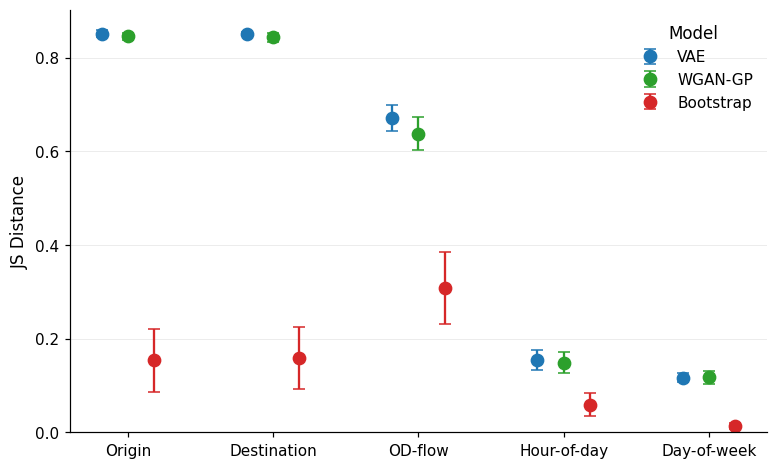

In [ ]:
# RQ1 Figure 1 — distributional fidelity (JS-distance family; lower = better, shared scale)
JS_FAMILY = {
             'origin_cell_js_distance': 'Origin',
             'dest_cell_js_distance': 'Destination',
             'od_flow_js_distance': 'OD-flow',
              'hour_js_distance':     'Hour-of-day',
              'dow_js_distance':      'Day-of-week'}
keys   = [k for k in JS_FAMILY if k in eval_df.columns]
labels = [JS_FAMILY[k] for k in keys]
x      = np.arange(len(keys))
dx     = {'VAE': -0.18, 'WGAN_GP': 0.0, 'Bootstrap': 0.18}

fig, ax = new_fig(figsize=(7.2, 4.4))
for mdl in MODELS:
    sub = eval_df[eval_df['model'] == mdl]
    means = [sub[k].mean() for k in keys]
    stds  = [sub[k].std()  for k in keys]
    ax.errorbar(x + dx[mdl], means, yerr=stds, fmt='o', linestyle='none',
                color=COLOURS[mdl], label=mlabel(mdl))
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('JS Distance')
#ax.set_title('RQ1 — Distributional fidelity')
ax.set_ylim(bottom=0)
ax.legend(title='Model')
fig.tight_layout(); save_fig(fig, 'rq1_fidelity_js_family'); plt.show()

saved: rq1_tstr_ratio.pdf -> outputs/figures


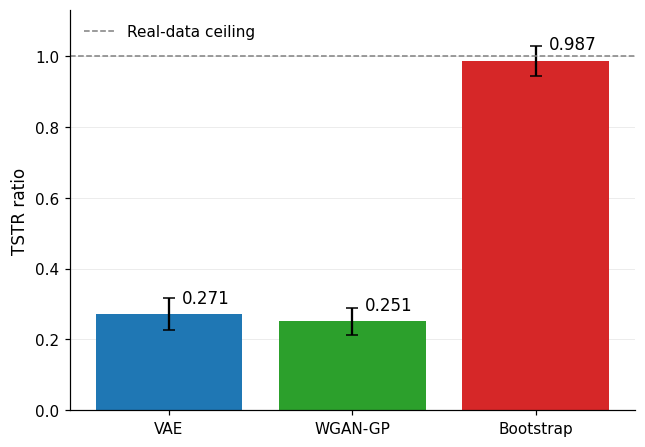

In [ ]:
# RQ1 Figure 2 — downstream utility (TSTR) as a bar plot with real-data ceiling
key = 'tstr_ratio'
stats = eval_df.groupby('model')[key].agg(['mean', 'std']).reindex(MODELS)

fig, ax = new_fig(figsize=(6, 4.2))
bars = ax.bar([mlabel(m) for m in MODELS], stats['mean'], yerr=stats['std'],
              capsize=4, color=[COLOURS[m] for m in MODELS])
ax.axhline(1.0, ls='--', c='grey', lw=1, label='Real-data ceiling')
for b, mu in zip(bars, stats['mean']):
    ax.text(b.get_x() + b.get_width() / 2 + 0.2, mu + 0.02, f'{mu:.3f}', ha='center', va='bottom')
ax.set_ylabel('TSTR ratio')
#ax.set_title('RQ1 — Downstream utility (train-synthetic, test-real)')
ax.set_ylim(0, max(1.1, float((stats['mean'] + stats['std']).max()) + 0.1))
ax.legend()
fig.tight_layout(); save_fig(fig, 'rq1_tstr_ratio'); plt.show()

### RQ2 — Privacy

saved: rq2_roc.pdf -> outputs/figures


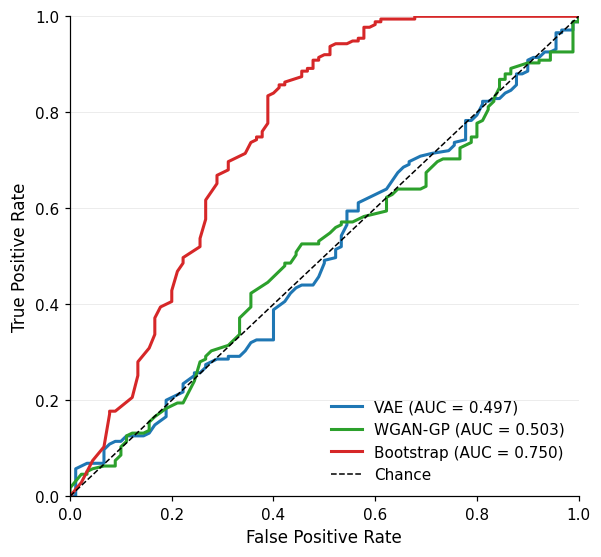

In [ ]:
# RQ2 Figure 1 — membership inference ROC (pooled over seeds)
fig, ax = new_fig('square')
for mdl in MODELS:
    d = pooled[pooled['model'] == mdl]
    fpr, tpr, _ = roc_curve(d['ground_truth'], d['membership_probability'])
    auc = roc_auc_score(d['ground_truth'], d['membership_probability'])
    ax.plot(fpr, tpr, color=COLOURS[mdl], lw=2, label=f'{mlabel(mdl)} (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
#ax.set_title('RQ2 — Membership inference ROC (pooled)')
ax.legend(loc='lower right')
fig.tight_layout(); save_fig(fig, 'rq2_roc'); plt.show()

saved: rq2_mia_auc.pdf -> outputs/figures


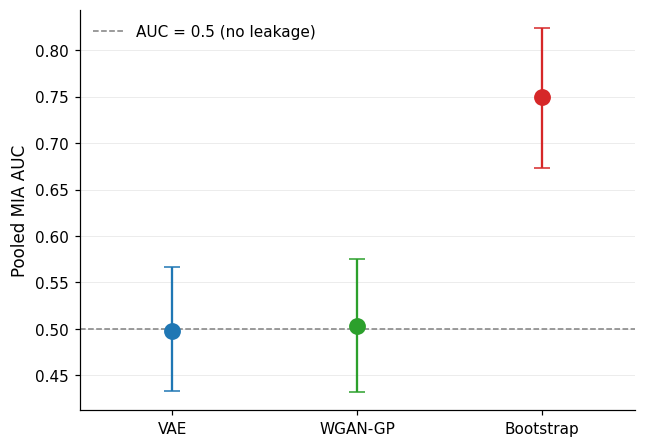

In [ ]:
# RQ2 Figure 2 — pooled MIA AUC with 95% bootstrap CI
fig, ax = new_fig(figsize=(6, 4.2))
for i, mdl in enumerate(MODELS):
    pt, ci = mia_boot[mdl]
    y, (lo, hi) = pt['auc'], ci['auc']
    ax.errorbar(i, y, yerr=[[y - lo], [hi - y]], fmt='o', ms=10, capsize=5, color=COLOURS[mdl])
ax.axhline(0.5, ls='--', c='grey', lw=1, label='AUC = 0.5 (no leakage)')
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels([mlabel(m) for m in MODELS])
ax.set_xlim(-0.5, len(MODELS) - 0.5)
ax.set_ylabel('Pooled MIA AUC')
#ax.set_title('RQ2 — Membership-inference leakage by model')
ax.legend()
fig.tight_layout(); save_fig(fig, 'rq2_mia_auc'); plt.show()

### RQ3 — Activity-group differential leakage

saved: rq3_mia_auc_by_group.pdf -> outputs/figures


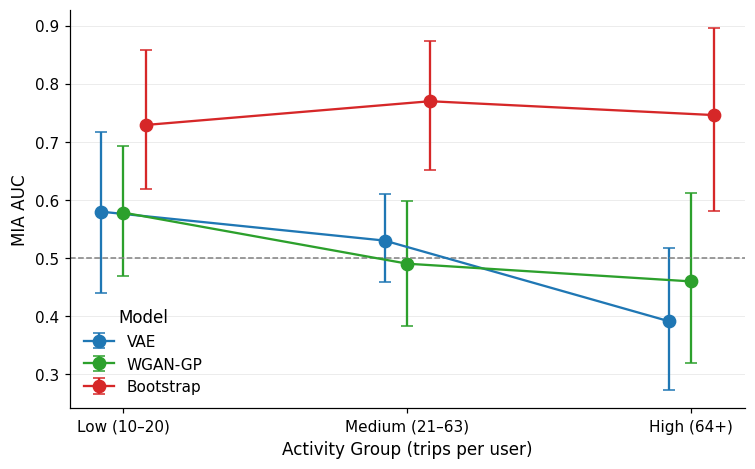

In [ ]:
# RQ3 Figure 1 — MIA AUC by activity group, all models on one axis
offsets = {'VAE': -0.08, 'WGAN_GP': 0.0, 'Bootstrap': +0.08}
xb = np.arange(len(GROUP_ORDER))

fig, ax = new_fig(figsize=(7.0, 4.4))
for mdl in MODELS:
    xs, ys, lo, hi = [], [], [], []
    for j, grp in enumerate(GROUP_ORDER):
        if (mdl, grp) not in mia_boot_by_group:
            continue
        pt, ci = mia_boot_by_group[(mdl, grp)]
        xs.append(xb[j] + offsets[mdl]); ys.append(pt['auc'])
        lo.append(pt['auc'] - ci['auc'][0]); hi.append(ci['auc'][1] - pt['auc'])
    if xs:
        ax.errorbar(xs, ys, yerr=[lo, hi], fmt='o-', capsize=4,
                    color=COLOURS[mdl], label=mlabel(mdl))
ax.axhline(0.5, ls='--', c='grey', lw=1)
ax.set_xticks(xb); ax.set_xticklabels(GROUP_ORDER)
ax.set_xlabel('Activity Group (trips per user)')
ax.set_ylabel('MIA AUC')
#ax.set_title('RQ3 — Membership inference by activity group')
ax.legend(title='Model')
fig.tight_layout(); save_fig(fig, 'rq3_mia_auc_by_group'); plt.show()

saved: rq3_near_copy_by_group.pdf -> outputs/figures


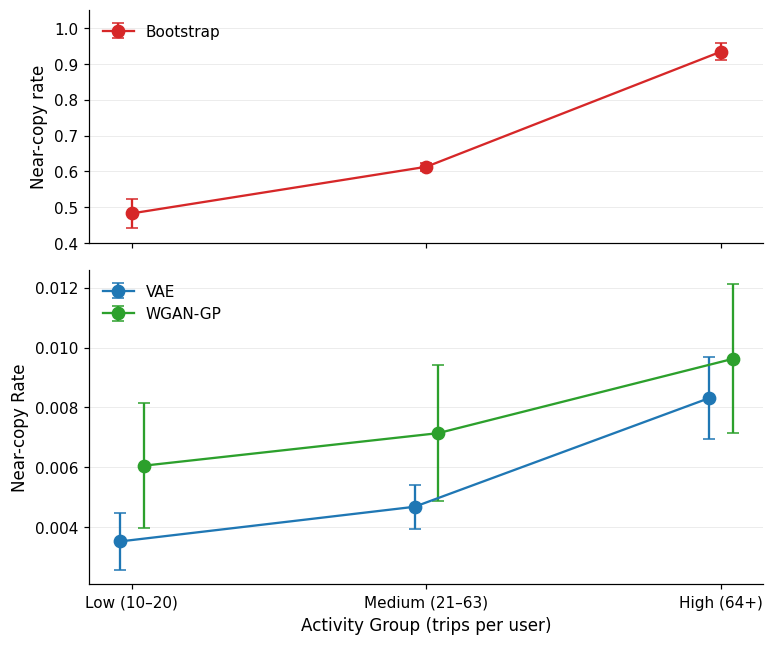

In [ ]:
# RQ3 Figure 2 — near-copy rate by activity group (stacked panels, shared x)
# Top: Bootstrap control. Bottom: deep generative models. Error bars = std over seeds.
NC = 'priv_near_copy_rate'
assert NC in group_eval.columns, f'{NC} not in group_eval'

def _nc(mdl, grp, stat):
    s = group_eval[(group_eval['model'] == mdl) & (group_eval['group'] == grp)][NC]
    return s.mean() if stat == 'mean' else s.std()

xb = np.arange(len(GROUP_ORDER))
fig, axes = new_fig(size='tall', nrows=2, sharex=True,
                    gridspec_kw={'height_ratios': [1, 1.35]})

# top — Bootstrap
ax = axes[0]; mdl = 'Bootstrap'
means = [_nc(mdl, g, 'mean') for g in GROUP_ORDER]
stds  = [_nc(mdl, g, 'std')  for g in GROUP_ORDER]
ax.errorbar(xb, means, yerr=stds, fmt='o-', capsize=4, color=COLOURS[mdl], label=mlabel(mdl))
ax.set_ylabel('Near-copy rate'); ax.legend(loc='best')
ymax = float(np.nanmax(np.array(means) + np.array(stds)))
ax.set_ylim(0.4, min(1.05, ymax * 1.15))

# bottom — VAE + WGAN-GP
ax = axes[1]; off = {'VAE': -0.04, 'WGAN_GP': +0.04}
for mdl in ['VAE', 'WGAN_GP']:
    xs = [xb[j] + off[mdl] for j in range(len(GROUP_ORDER))]
    means = [_nc(mdl, g, 'mean') for g in GROUP_ORDER]
    stds  = [_nc(mdl, g, 'std')  for g in GROUP_ORDER]
    ax.errorbar(xs, means, yerr=stds, fmt='o-', capsize=4, color=COLOURS[mdl], label=mlabel(mdl))
ax.set_ylabel('Near-copy Rate'); ax.set_xlabel('Activity Group (trips per user)')
ax.set_xticks(xb); ax.set_xticklabels(GROUP_ORDER); ax.legend(loc='best')

#fig.suptitle('RQ3 — Record reproduction by activity group', y=0.99)
fig.tight_layout(); save_fig(fig, 'rq3_near_copy_by_group'); plt.show()

### Discussion — privacy vs utility trade-off

saved: tradeoff_discussion.pdf -> outputs/figures


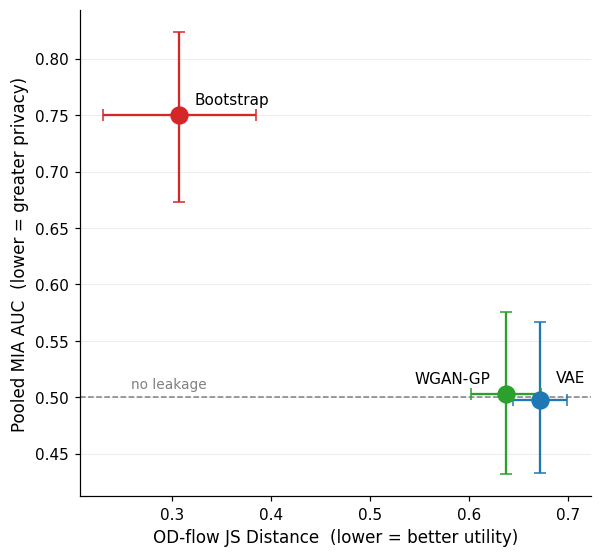

In [ ]:
# Discussion Figure — OD-flow JS distance (x) vs pooled MIA AUC (y)

XKEY = 'od_flow_js_distance' if 'od_flow_js_distance' in eval_df.columns else 'od_flow_jsd'
u = eval_df.groupby('model')[XKEY].agg(['mean', 'std']).reindex(MODELS)

LABEL_OFFSETS = {
    'VAE': (10, 15),
    'WGAN_GP': (-60, 10),
    'Bootstrap': (10, 10),
}

fig, ax = new_fig('square')

for mdl in MODELS:
    pt, ci = mia_boot[mdl]

    xm = u.loc[mdl, 'mean']
    xs = u.loc[mdl, 'std']

    y = pt['auc']
    lo, hi = ci['auc']

    ax.errorbar(
        xm, y,
        xerr=xs,
        yerr=[[y - lo], [hi - y]],
        fmt='o',
        ms=11,
        capsize=4,
        color=COLOURS[mdl],
        zorder=3
    )

    dx, dy = LABEL_OFFSETS.get(mdl, (9, 5))

    ax.annotate(
        mlabel(mdl),
        xy=(xm, y),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=10
    )

ax.axhline(0.5, ls='--', c='grey', lw=1)

ax.text(
    0.10, 0.505,
    'no leakage',
    transform=ax.get_yaxis_transform(),
    ha='left',
    va='bottom',
    color='grey',
    fontsize=9
)

ax.set_xlabel('OD-flow JS Distance  (lower = better utility)')
ax.set_ylabel('Pooled MIA AUC  (lower = greater privacy)')

fig.tight_layout()
save_fig(fig, 'tradeoff_discussion')
plt.show()

# Data Visualisation

In [ ]:
pip install h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.8 MB/s eta 0:00:00


saved: spatial_od_2x2_seed111.pdf -> outputs/figures
saved: spatial_od_grid_allseeds.pdf -> outputs/figures


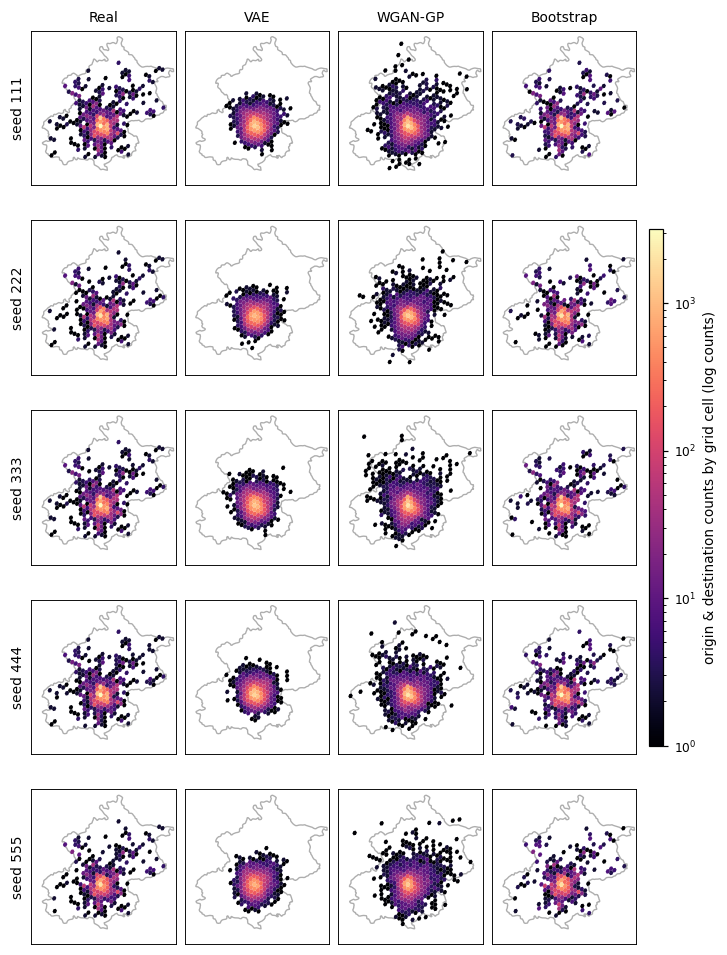

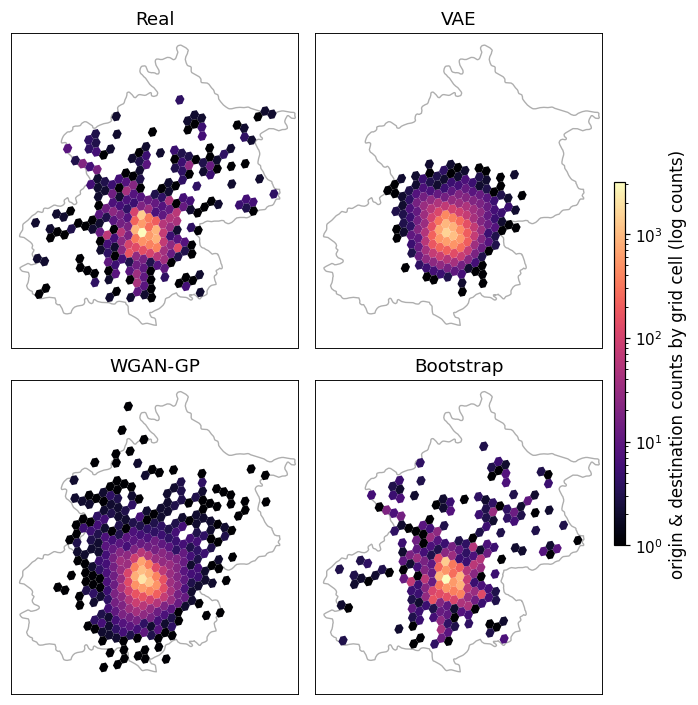

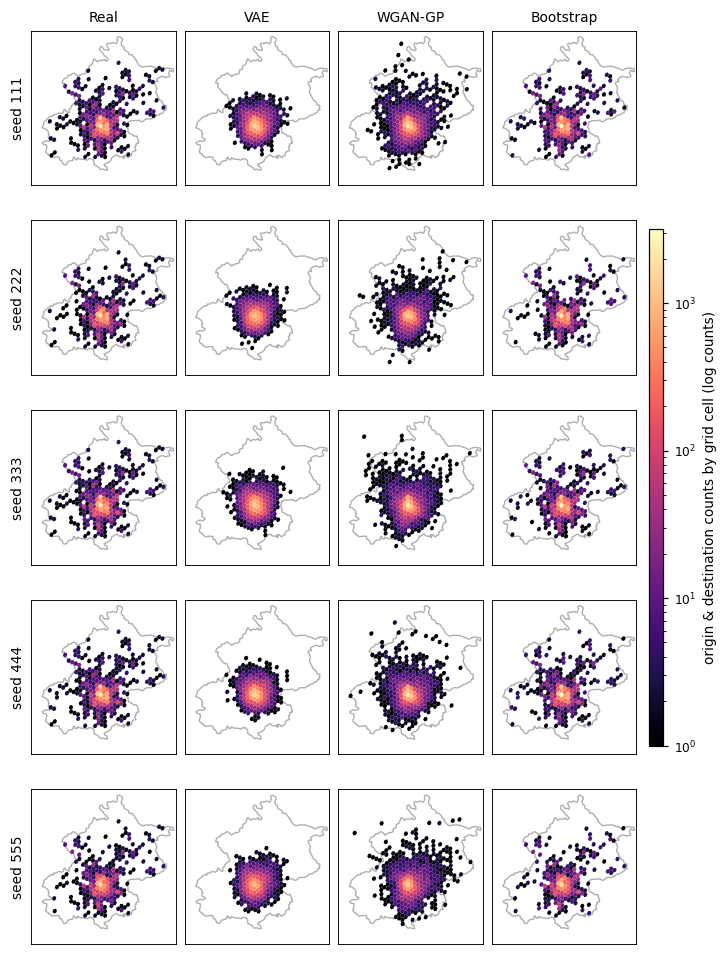

In [ ]:
# ============================================================
# Spatial OD density comparison — H3 res-6 choropleth, shared scale
# ============================================================
import os, json, zipfile, urllib.request
import h3
from collections import Counter
from matplotlib.collections import PolyCollection
import matplotlib.colors as mcolors

# ---- data / mapping config ----
DATA_PATH = 'od_trips_20260410_input.csv'   # <-- real-data CSV
H3_RES    = 6
WHICH     = 'both'           # 'start' | 'end' | 'both'
REAL_REF  = 'train'           # 'full' | 'train'
CMAP      = 'magma'
CBAR_LABEL = 'origin & destination counts by grid cell (log counts)'

START_LAT, START_LON = 'start_centroid_lat', 'start_centroid_lon'
END_LAT,   END_LON   = 'end_centroid_lat',   'end_centroid_lon'
MAIN_TRAIN_SPLITS = ('low_activity_main_train', 'shadow', 'eval_in')

# ---- boundary config (GADM L1, WGS84) ----
BEIJING_BOUNDARY_SRC = 'gadm41_CHN_1.json.zip'
BOUNDARY_NAME_FIELD  = 'NAME_1'
BOUNDARY_NAME_VALUE  = 'Beijing'
BOUNDARY_COLOUR = '0.55'
BOUNDARY_LW     = 0.9
BOUNDARY_ALPHA  = 0.7

real_full = pd.read_csv(DATA_PATH)

def _read_geojson(src):
    if src.endswith('.zip'):
        with zipfile.ZipFile(src) as z:
            name = next(n for n in z.namelist()
                        if n.lower().endswith(('.json', '.geojson')))
            with z.open(name) as f:
                return json.load(f)
    if src.startswith('http'):
        cache = os.path.basename(src)
        if not os.path.exists(cache):
            urllib.request.urlretrieve(src, cache)
        return json.load(open(cache))
    return json.load(open(src))

def _load_boundary_rings(src=BEIJING_BOUNDARY_SRC,
                         field=BOUNDARY_NAME_FIELD, value=BOUNDARY_NAME_VALUE):
    try:
        gj = _read_geojson(src)
    except Exception as e:
        print('  [boundary] could not load outline:', e)
        return []
    rings = []
    for feat in gj.get('features', [gj]):
        props = feat.get('properties', {}) or {}
        if value is not None and props.get(field) != value:
            continue
        geom = feat.get('geometry', feat) or {}
        gtype, coords = geom.get('type'), geom.get('coordinates', [])
        polys = [coords] if gtype == 'Polygon' else coords if gtype == 'MultiPolygon' else []
        for poly in polys:
            for ring in poly:
                rings.append(np.asarray(ring, float))   # (N, 2) lon, lat
    if not rings:
        print(f'  [boundary] no feature matched {field}={value!r}')
    return rings

_BOUNDARY_RINGS = _load_boundary_rings()

def _add_boundary(ax):
    for ring in _BOUNDARY_RINGS:
        ax.plot(ring[:, 0], ring[:, 1], color=BOUNDARY_COLOUR,
                lw=BOUNDARY_LW, alpha=BOUNDARY_ALPHA, zorder=0.5)

# ---- panel sources ----
def _real_panel(seed):
    if REAL_REF == 'full':
        return real_full
    us = pd.read_csv(SPLIT_DIR / f'user_summary_seed{seed}.csv')
    users = us.loc[us['split'].isin(MAIN_TRAIN_SPLITS), 'user_id']
    return real_full[real_full['user_id'].isin(users)]

def _synth_panel(model, seed):
    return pd.read_csv(ARTIFACT_ROOT / model / f'{model.lower()}_seed{seed}.csv')

# ---- H3 counting + geometry ----
def _cell_counts(d, which=WHICH, res=H3_RES):
    pairs = {'start': [(START_LAT, START_LON)],
             'end':   [(END_LAT,   END_LON)],
             'both':  [(START_LAT, START_LON), (END_LAT, END_LON)]}[which]
    c = Counter()
    for lat, lon in pairs:
        sub = d[[lat, lon]].dropna()
        c.update(h3.latlng_to_cell(a, b, res) for a, b in sub.itertuples(index=False))
    return c

_CELLPOLY = {}
def _poly(cell):                      # h3 v4: (lat, lng) -> mpl (x=lon, y=lat)
    if cell not in _CELLPOLY:
        _CELLPOLY[cell] = [(lng, lat) for lat, lng in h3.cell_to_boundary(cell)]
    return _CELLPOLY[cell]

def _draw(ax, counts, norm, extent, lat0):
    coll = None
    if counts:
        cells = list(counts)
        coll = PolyCollection([_poly(c) for c in cells],
                              array=np.array([counts[c] for c in cells], float),
                              cmap=CMAP, norm=norm, edgecolors='none')
        ax.add_collection(coll)
    _add_boundary(ax)
    ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
    ax.set_aspect(1.0 / np.cos(np.radians(lat0)))
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(True); s.set_linewidth(0.6)
    return coll

# ---- shared-scale grid driver ----
def spatial_grid(panels, nrows, ncols, figsize, fname,
                 titles=None, col_titles=None, row_titles=None,
                 margin=0.08,            # extent padding (fraction of data span) -> zoom
                 title_fs=12, label_fs=11, cbar_fs=10, cbar_label_fs=11):
    counts = [_cell_counts(d) for d in panels]
    vmax = max((max(c.values()) for c in counts if c), default=1)
    norm = mcolors.LogNorm(vmin=1, vmax=vmax)

    allcells = set().union(*[set(c) for c in counts]) or {next(iter(counts[0]))}
    pts = np.array([p for cell in allcells for p in _poly(cell)])
    (xmin, ymin), (xmax, ymax) = pts.min(0), pts.max(0)
    mx, my = (xmax - xmin) * margin, (ymax - ymin) * margin
    extent = (xmin - mx, xmax + mx, ymin - my, ymax + my)
    lat0 = 0.5 * (extent[2] + extent[3])

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             squeeze=False, constrained_layout=True)
    mappable = None
    for ax, cnt in zip(axes.ravel(), counts):
        c = _draw(ax, cnt, norm, extent, lat0)
        mappable = mappable or c

    if titles:
        for ax, t in zip(axes.ravel(), titles):
            ax.set_title(t, fontsize=title_fs)
    if col_titles:
        for j, t in enumerate(col_titles):
            axes[0, j].set_title(t, fontsize=title_fs)
    if row_titles:
        for i, t in enumerate(row_titles):
            axes[i, 0].set_ylabel(t, rotation=90, fontsize=label_fs)

    cb = fig.colorbar(mappable, ax=axes, shrink=0.55, aspect=35, pad=0.02)
    cb.ax.tick_params(labelsize=cbar_fs)
    cb.set_label(CBAR_LABEL, fontsize=cbar_label_fs)
    save_fig(fig, fname)
    return fig

# ---- Figure A: 2x2, seed 111 ----
SEED_MAIN = 111
panels_A = [_real_panel(SEED_MAIN),
            _synth_panel('VAE',       SEED_MAIN),
            _synth_panel('WGAN_GP',   SEED_MAIN),
            _synth_panel('Bootstrap', SEED_MAIN)]
spatial_grid(panels_A, 2, 2, figsize=(6.3, 6.3),
             titles=['Real', mlabel('VAE'), mlabel('WGAN_GP'), mlabel('Bootstrap')],
             fname='spatial_od_2x2_seed111',
             margin=0.08, title_fs=12, cbar_fs=10, cbar_label_fs=11)

# ---- Figure B: 5x4 appendix ----
panels_B = []
for seed in SEEDS:
    panels_B.append(_real_panel(seed))
    for model in MODELS:
        panels_B.append(_synth_panel(model, seed))
spatial_grid(panels_B, len(SEEDS), 1 + len(MODELS),
             figsize=(6.5, 8.7),        # ~ \textwidth × most of \textheight
             col_titles=['Real'] + [mlabel(m) for m in MODELS],
             row_titles=[f'seed {s}' for s in SEEDS],
             fname='spatial_od_grid_allseeds',
             margin=0.08,
             title_fs=9, label_fs=9, cbar_fs=8, cbar_label_fs=9)

saved: hourly_trips_seed111.pdf -> outputs/figures


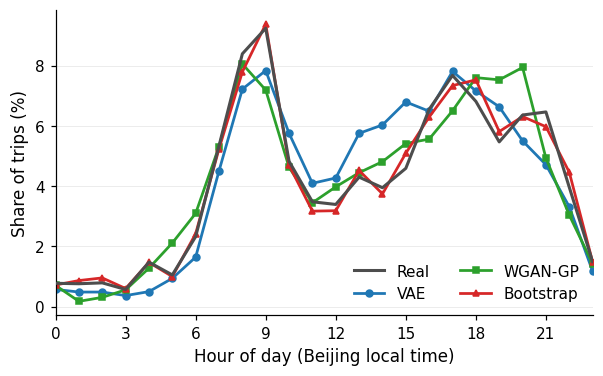

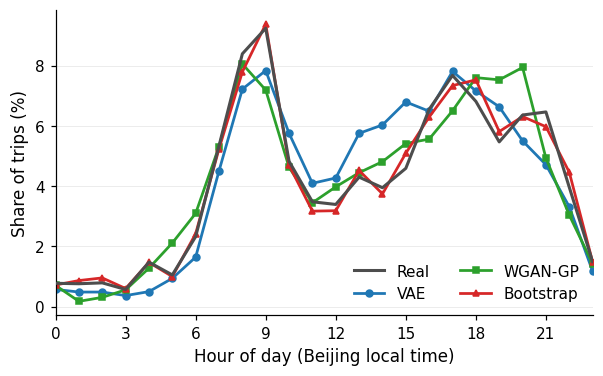

In [ ]:
# ============================================================
# Temporal utility — trips by hour of day (Beijing local, UTC+8)
# ============================================================
UTC_OFFSET = 8                                  # GeoLife logs in GMT; Beijing = UTC+8 (no DST)
MARKERS = {'VAE': 'o', 'WGAN_GP': 's', 'Bootstrap': '^'}

def _hours(d, offset=UTC_OFFSET):
    if 'start_time' in d.columns:
        t = pd.to_datetime(d['start_time'], errors='coerce') + pd.Timedelta(hours=offset)
        return t.dt.hour.dropna().to_numpy()
    if 'hour' in d.columns:
        return ((d['hour'].dropna().round().astype(int) + offset) % 24).to_numpy()
    raise KeyError('panel has neither start_time nor hour (apply inverse_transform patch + regenerate)')

def _hour_curve(d, normalise=True):
    counts = np.bincount(_hours(d), minlength=24)[:24].astype(float)
    return 100.0 * counts / counts.sum() if normalise else counts

def hourly_trips_lineplot(seed, fname, normalise=True, figsize=(6.3, 3.6),
                          label_fs=11, tick_fs=10, legend_fs=10):
    hours = np.arange(24)
    fig, ax = new_fig(figsize=figsize)

    ax.plot(hours, _hour_curve(_real_panel(seed), normalise),
            color='0.3', lw=2.0, label='Real', zorder=3)
    for model in MODELS:
        ax.plot(hours, _hour_curve(_synth_panel(model, seed), normalise),
                color=COLOURS[model], lw=1.8,
                marker=MARKERS[model], ms=4.5, markevery=1,
                label=mlabel(model))

    ax.set_xlabel('Hour of day (Beijing local time)', fontsize=label_fs)
    ax.set_ylabel('Share of trips (%)' if normalise else 'Trip count',
                  fontsize=label_fs)
    ax.set_xlim(0, 23); ax.set_xticks(range(0, 24, 3))
    ax.tick_params(labelsize=tick_fs)
    ax.legend(fontsize=legend_fs, ncol=2)
    save_fig(fig, fname)
    return fig

hourly_trips_lineplot(111, 'hourly_trips_seed111')

saved: temporal_rhythm.pdf -> outputs/figures
saved: ecdf_trips_per_user.pdf -> outputs/figures


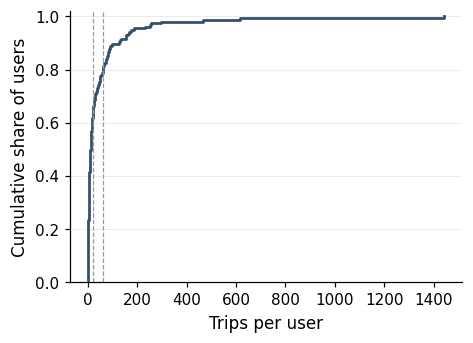

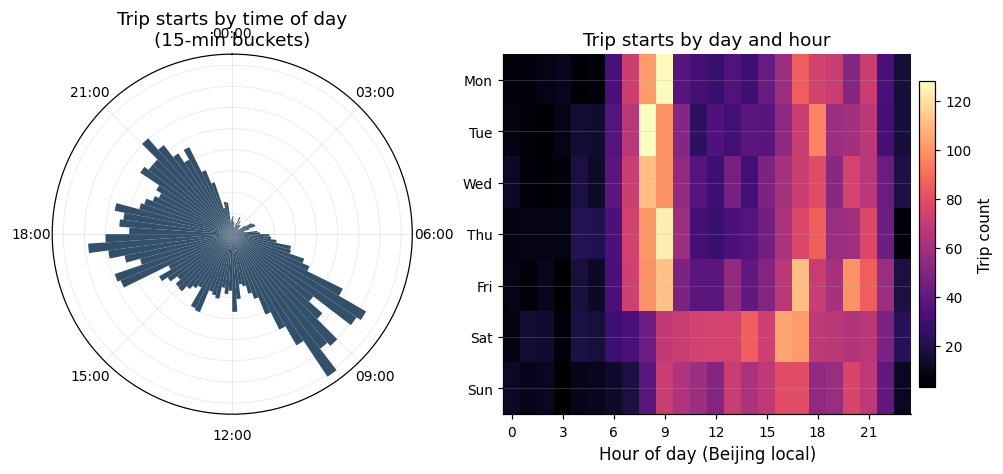

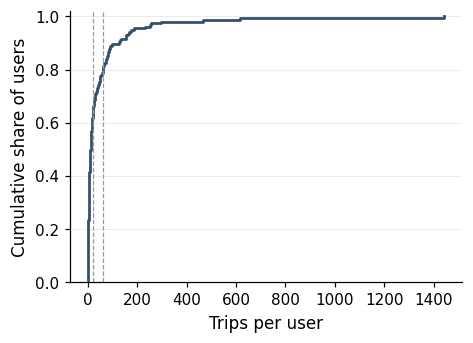

In [ ]:
# ============================================================
# Descriptive figures — temporal rhythm + per-user activity
# Reuses: real_full, CMAP, new_fig, save_fig, UTC_OFFSET (falls back to 8)
# ============================================================
UTC_OFFSET = globals().get('UTC_OFFSET', 8)   # Beijing local, no DST
ACCENT = '#33506b'

def _local_dt(d, offset=UTC_OFFSET):
    return (pd.to_datetime(d['start_time'], errors='coerce')
            + pd.Timedelta(hours=offset)).dropna()

# ---------- Figure 1: wagon wheel (15-min) + weekly heatmap ----------
def temporal_rhythm_fig(fname='temporal_rhythm',
                        figsize=(9.0, 4.2),
                        title_fs=12, tick_fs=9, cbar_fs=9, cbar_label_fs=10):
    dt = _local_dt(real_full)
    bucket15 = ((dt.dt.hour * 60 + dt.dt.minute) // 15).to_numpy()      # 0..95
    hour     = dt.dt.hour.to_numpy()                                    # 0..23
    dow      = dt.dt.dayofweek.to_numpy()                               # 0=Mon..6=Sun

    fig = plt.figure(figsize=figsize, constrained_layout=True)

    # --- wagon wheel (polar, 96 x 15-min spokes) ---
    axw = fig.add_subplot(1, 2, 1, projection='polar')
    counts = np.bincount(bucket15, minlength=96).astype(float)
    theta = (np.arange(96) + 0.5) / 96 * 2 * np.pi
    axw.bar(theta, counts, width=2 * np.pi / 96, color=ACCENT,
            edgecolor='none', align='center')
    axw.set_theta_zero_location('N'); axw.set_theta_direction(-1)       # clock layout
    axw.set_xticks(np.arange(0, 24, 3) / 24 * 2 * np.pi)
    axw.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], fontsize=tick_fs)
    axw.set_yticklabels([])
    axw.set_title('Trip starts by time of day\n(15-min buckets)', fontsize=title_fs)

    # --- weekly heatmap (day-of-week x hour) ---
    axh = fig.add_subplot(1, 2, 2)
    mat = np.zeros((7, 24))
    np.add.at(mat, (dow, hour), 1)
    im = axh.imshow(mat, aspect='auto', cmap=CMAP, origin='upper')
    axh.set_yticks(range(7))
    axh.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], fontsize=tick_fs)
    axh.set_xticks(range(0, 24, 3))
    axh.set_xticklabels(range(0, 24, 3), fontsize=tick_fs)
    axh.set_xlabel('Hour of day (Beijing local)', fontsize=title_fs - 1)
    axh.set_title('Trip starts by day and hour', fontsize=title_fs)
    cb = fig.colorbar(im, ax=axh, shrink=0.85, pad=0.02)
    cb.ax.tick_params(labelsize=cbar_fs)
    cb.set_label('Trip count', fontsize=cbar_label_fs)

    save_fig(fig, fname)
    return fig

# ---------- Figure 2: ECDF of trips per user ----------
def ecdf_trips_per_user(fname='ecdf_trips_per_user',
                        figsize=(4.6, 3.2), mark_groups=True,
                        label_fs=11, tick_fs=10):
    n = real_full.groupby('user_id').size().sort_values().to_numpy()
    y = np.arange(1, len(n) + 1) / len(n)

    fig, ax = new_fig(figsize=figsize)
    ax.step(n, y, where='post', color=ACCENT, lw=1.8)
    if mark_groups:                                   # RQ3 activity-band thresholds
        for thr in (20.5, 63.5):
            ax.axvline(thr, color='0.6', ls='--', lw=0.8)
    ax.set_xlabel('Trips per user', fontsize=label_fs)
    ax.set_ylabel('Cumulative share of users', fontsize=label_fs)
    ax.set_ylim(0, 1.02)
    ax.tick_params(labelsize=tick_fs)
    save_fig(fig, fname)
    return fig

temporal_rhythm_fig()
ecdf_trips_per_user()

In [ ]:
df = pd.read_csv('od_trips_20260410_input.csv')
df.head()

In [ ]:
# ============================================================
# Descriptive temporal + activity figures (visualisation_v4 style)
# Active = trips IN PROGRESS (duration-aware occupancy), per originals
# ============================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

UTC_OFFSET = 8        # Beijing local (no DST). Set 0 to reproduce the UTC originals.

# robust save helper (works in either notebook)
try:
    save_fig
except NameError:
    from pathlib import Path
    FIG_DIR = Path('outputs/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
    def save_fig(fig, name, formats=('pdf',)):
        for ext in formats:
            fig.savefig(FIG_DIR / f'{name}.{ext}', bbox_inches='tight', dpi=200)
        print('saved:', name, '->', FIG_DIR)

_d = df.copy()
_d['start_time'] = pd.to_datetime(_d['start_time'], errors='coerce') + pd.Timedelta(hours=UTC_OFFSET)
_d = _d.dropna(subset=['start_time'])
_d['end_time'] = _d['start_time'] + pd.to_timedelta(_d['duration_minutes'], unit='m')

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# ---------- Figure 1: active-trips wheel (15-min) + weekly heatmap ----------
def active_trips_fig(fname='active_trips_rhythm', figsize=(13, 6),
                     title_fs=13, tick_fs=10, cbar_fs=9):
    # --- 15-min occupancy for the wheel ---
    bin_minutes, n_bins = 15, int(24 * 60 / 15)
    active = np.zeros(n_bins)
    for _, r in _d.iterrows():
        s = r['start_time'].hour * 60 + r['start_time'].minute
        e = r['end_time'].hour * 60 + r['end_time'].minute
        sb, eb = s // bin_minutes, e // bin_minutes
        bins = (range(sb, eb + 1) if r['end_time'].date() == r['start_time'].date()
                else list(range(sb, n_bins)) + list(range(0, eb + 1)))
        for b in bins:
            active[b % n_bins] += 1

    # --- hourly occupancy for the heatmap (per active weekday-hour) ---
    rows = []
    for _, r in _d.iterrows():
        cur = r['start_time'].floor('h')
        while cur <= r['end_time']:
            rows.append((cur.day_name(), cur.hour)); cur += pd.Timedelta(hours=1)
    pivot = (pd.DataFrame(rows, columns=['day', 'hour'])
             .pivot_table(index='day', columns='hour', aggfunc='size', fill_value=0)
             .reindex(DAY_ORDER[::-1]))

    fig = plt.figure(figsize=figsize, constrained_layout=True)


    axw = fig.add_subplot(1, 2, 1, projection='polar')
    ang = 2 * np.pi * np.arange(n_bins) / n_bins
    ang = np.concatenate([ang, [ang[0]]])
    val = np.concatenate([active, [active[0]]])
    axw.plot(ang, val, lw=2); axw.fill(ang, val, alpha=0.3)
    axw.set_theta_zero_location('N'); axw.set_theta_direction(-1)
    axw.set_xticks(2 * np.pi * np.arange(0, n_bins, 4) / n_bins)
    axw.set_xticklabels([f'{h:02d}:00' for h in range(24)], fontsize=tick_fs)

    # --- radial (count) axis ---
    axw.set_rlabel_position(45)                       # tuck ticks into a quiet gap
    axw.tick_params(axis='y', labelsize=tick_fs - 1)
    #axw.set_ylabel('Active trips', fontsize=title_fs - 2, labelpad=22)
    for lbl in axw.get_yticklabels():                    # legibility over the fill
        lbl.set_bbox(dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.7))

    #axw.set_title('Active Trips by Time of Day\n(15-min buckets)', fontsize=title_fs, y=1.08)


    axh = fig.add_subplot(1, 2, 2)
    sns.heatmap(pivot, cmap='magma', ax=axh, cbar_kws={'label': 'Active trips'})
    #axh.set_title('Active Trips by Day and Hour', fontsize=title_fs)
    axh.set_xlabel('Hour of Day (local time)', fontsize=title_fs - 2)
    #axh.set_ylabel('Day of Week', fontsize=title_fs - 2)
    axh.tick_params(labelsize=tick_fs)
    axh.set_ylabel('')
    axh.collections[0].colorbar.ax.tick_params(labelsize=cbar_fs)

    save_fig(fig, fname); return fig


saved: ecdf_trips_per_user.pdf -> outputs/figures


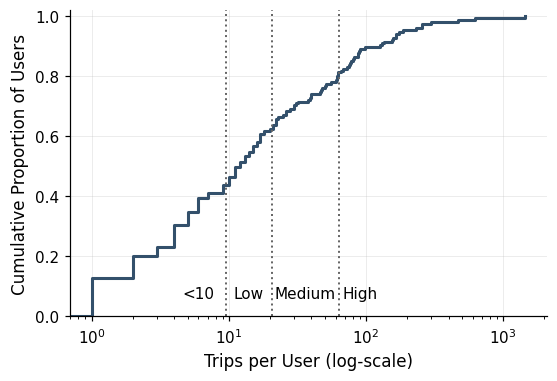

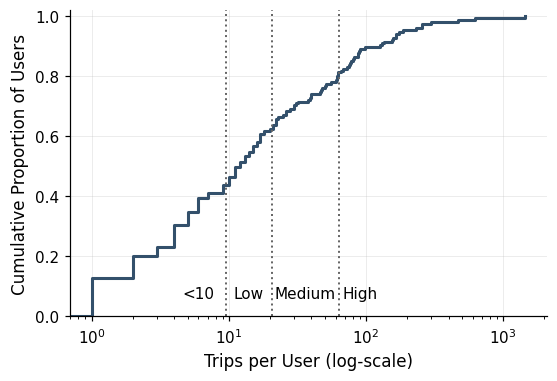

In [ ]:
# ---------- Figure 2: ECDF of trips per user (log x) ----------
def ecdf_trips_per_user(
        fname='ecdf_trips_per_user',
        figsize=(5.2, 3.6),
        label_fs=11,
        tick_fs=10,
        title_fs=12,
        mark_groups=True):

    utc = (
        df.groupby('user_id')
          .size()
          .reset_index(name='n_trips')
    )

    fig, ax = plt.subplots(figsize=figsize)

    sns.ecdfplot(
        data=utc,
        x='n_trips',
        ax=ax,
        lw=2,
        color=ACCENT
    )

    # log x-axis
    ax.set_xscale('log')

    # activity-group boundaries
    if mark_groups:
        for thr, lab in [(9.5, '10'), (20.5, '21'), (63.5, '64')]:
            ax.axvline(thr, linestyle='dotted', lw=1.3, color='0.4')
            #ax.text(thr, 0.02, f' {lab}', rotation=90, va='bottom', ha='left',
                    #fontsize=tick_fs - 1, color='0.4')

        vert_align = 0.1
        # labels centred approximately on the log scale
        ax.text(6, vert_align, '<10',
                ha='center', va='top',
                fontsize=tick_fs)

        ax.text(14, vert_align, 'Low',
                ha='center', va='top',
                fontsize=tick_fs)

        ax.text(36, vert_align, 'Medium',
                ha='center', va='top',
                fontsize=tick_fs)

        ax.text(90, vert_align, 'High',
                ha='center', va='top',
                fontsize=tick_fs)

    ax.set_xlabel(
        'Trips per User (log-scale)',
        fontsize=label_fs
    )

    ax.set_ylabel(
        'Cumulative Proportion of Users',
        fontsize=label_fs
    )

    ax.set_ylim(0, 1.02)

    ax.tick_params(labelsize=tick_fs)

    # optional: cleaner major grid only
    ax.grid(True, which='major', axis='both', alpha=0.25)
    ax.grid(False, which='minor')

    fig.tight_layout()
    save_fig(fig, fname)
    return fig


ecdf_trips_per_user()

In [ ]:
from src.user_split import (
    load_and_filter_trip_data, build_user_summary, get_users_by_split,
    get_main_training_users, get_user_trips,
)

DATA_PATH = 'od_trips_20260410_input.csv'   # <-- real-data CSV

df = load_and_filter_trip_data(DATA_PATH)
df.head()

Removed rows: 30
Percent removed: 0.39


In [ ]:
df[['duration_minutes','centroid_dist','centroid_speed_kmh']].describe()

,duration_minutes,centroid_dist,centroid_speed_kmh
count,7739.000000,7739.000000,7739.000000
mean,28.683783,13553.162766,42.828813
std,30.284057,9824.495511,26.538662
min,5.000000,4967.378530,1.465069
25%,10.833333,9053.475046,21.965417
50%,18.850000,11412.839681,36.832493
75%,35.191667,14440.156931,58.575591
max,353.500000,95261.075642,148.671243


In [ ]:
df.columns

Index(['trip_id', 'user_id', 'session_id', 'start_time', 'end_time',
       'duration_minutes', 'start_hex', 'end_hex', 'n_points', 'inter_hex_num',
       'avg_gps_splits', 'traj_start_lat', 'traj_start_lon', 'traj_end_lat',
       'traj_end_lon', 'traj_dist_m', 'mode', 'start_centroid_lat',
       'start_centroid_lon', 'end_centroid_lat', 'end_centroid_lon',
       'centroid_dist', 'centroid_speed_kmh'],
      dtype='object')

In [ ]:
df['user_id'].nunique()

154

## Training Losses Plot

In [4]:
pip install h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from src.feature_pipeline import ODFeaturePipeline
from src.models.wrappers import GeneratorWrapper
from src.models.vae import VAEModel
from src.models.wgan_gp import WGANModel

mpl.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm", "font.size": 9})

MODELS = {
    'VAE': (VAEModel,
            {'latent_dim': 16, 'lr': 1e-3, 'beta': 0.05},
            {'epochs': 80, 'batch_size': 64, 'val_size': 0.1, "kl_warmup_frac": 0.4, 'random_state': 111}),

    'WGAN_GP': (WGANModel,
                {'noise_dim': 32, 'hidden_dim': 512, 'lr': 1e-4,
                 'lambda_gp': 5.0, 'critic_steps': 5},
                {'epochs': 200, 'batch_size': 64, 'val_size': 0.1, 'random_state': 111}),
}

# --- train via the wrapper, identical to the main pipeline ---
histories = {}
for name, (cls, model_params, train_params) in MODELS.items():
    model = cls(**model_params)
    histories[name] = model.fit(train_loader, val_loader, **train_params)

# ============================ VAE figure ============================
h = histories['VAE']
ep = np.arange(1, len(h["recon"]) + 1)
fig, (a, b) = plt.subplots(1, 2, figsize=(6.5, 2.7))

a.plot(ep, h["recon"], color="#1f77b4", label="Train")
a.plot(ep, h["val_recon"], color="#d62728", ls="--", label="Validation")
a.set_xlabel("Epoch"); a.set_ylabel("MSE reconstruction loss")
a.set_title("(a)", loc="left"); a.legend(frameon=False)

b.plot(ep, h["kl"], color="#1f77b4", label="KL divergence")
b.set_xlabel("Epoch"); b.set_ylabel(r"KL divergence $D_{\mathrm{KL}}$")
b.set_title("(b)", loc="left")
bb = b.twinx()
bb.plot(ep, h["beta"], color="0.6", ls=":", label=r"$\beta$ schedule")
bb.set_ylabel(r"KL weight $\beta$", color="0.4"); bb.tick_params(axis="y", colors="0.4")
lines = b.get_lines() + bb.get_lines()
b.legend(lines, [l.get_label() for l in lines], frameon=False, loc="lower right")
fig.tight_layout(); plt.show()

# ============================ WGAN-GP figure ============================
h = histories['WGAN_GP']
ep = np.arange(1, len(h["c_loss"]) + 1)
c = pd.Series(h["c_loss"]); g = pd.Series(h["g_loss"]); w = 5

fig, ax = plt.subplots(figsize=(5.6, 3.0))
ax.axhline(0, color="0.85", lw=0.8, zorder=0)
ax.plot(ep, c, color="#1f77b4", alpha=0.25)
ax.plot(ep, c.rolling(w, min_periods=1).mean(), color="#1f77b4")
ax.set_xlabel("Epoch"); ax.set_ylabel(r"Critic loss ($\approx -W$)", color="#1f77b4")
ax.tick_params(axis="y", colors="#1f77b4")

ax2 = ax.twinx()
ax2.plot(ep, g, color="#2ca02c", alpha=0.25)
ax2.plot(ep, g.rolling(w, min_periods=1).mean(), color="#2ca02c")
ax2.set_ylabel("Generator loss", color="#2ca02c"); ax2.tick_params(axis="y", colors="#2ca02c")

ax.plot([], [], color="#1f77b4", label="Critic loss")
ax.plot([], [], color="#2ca02c", label="Generator loss")
ax.legend(frameon=False, loc="best")
fig.tight_layout(); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm", "font.size": 9})
SEED = 111

# --- train both at the final config (Table 2) ---
vae = VAEModel(latent_dim=16, lr=1e-3, beta= 0.05)
vae_hist = vae.fit(train_loader, val_loader, epochs=80, kl_warmup_frac=0.4, random_state=SEED)

wgan = WGANModel(input_dim=D, noise_dim=64, hidden_dim=128, lr=1e-4,
                 betas=(0.5, 0.9), lambda_gp=10.0, critic_steps=3)  # NB: 3, not the default 5
wgan_hist = wgan.fit(train_loader, epochs=100, random_state=SEED)

# ============================ VAE figure ============================
ep = np.arange(1, len(vae_hist["recon"]) + 1)
fig, (a, b) = plt.subplots(1, 2, figsize=(6.5, 2.7))

a.plot(ep, vae_hist["recon"], color="#1f77b4", label="Train")
a.plot(ep, vae_hist["val_recon"], color="#d62728", ls="--", label="Validation")
a.set_xlabel("Epoch"); a.set_ylabel("MSE reconstruction loss")
a.set_title("(a)", loc="left"); a.legend(frameon=False)

b.plot(ep, vae_hist["kl"], color="#1f77b4", label="KL divergence")
b.set_xlabel("Epoch"); b.set_ylabel(r"KL divergence $D_{\mathrm{KL}}$")
b.set_title("(b)", loc="left")
bb = b.twinx()
bb.plot(ep, vae_hist["beta"], color="0.6", ls=":", label=r"$\beta$ schedule")
bb.set_ylabel(r"KL weight $\beta$", color="0.4"); bb.tick_params(axis="y", colors="0.4")
lines = b.get_lines() + bb.get_lines()
b.legend(lines, [l.get_label() for l in lines], frameon=False, loc="lower right")
fig.tight_layout(); plt.show()

# ============================ WGAN-GP figure ============================
import pandas as pd
ep = np.arange(1, len(wgan_hist["c_loss"]) + 1)
c = pd.Series(wgan_hist["c_loss"]); g = pd.Series(wgan_hist["g_loss"]); w = 5

fig, ax = plt.subplots(figsize=(5.6, 3.0))
ax.axhline(0, color="0.85", lw=0.8, zorder=0)
ax.plot(ep, c, color="#1f77b4", alpha=0.25)
ax.plot(ep, c.rolling(w, min_periods=1).mean(), color="#1f77b4", label="Critic loss")
ax.set_xlabel("Epoch"); ax.set_ylabel(r"Critic loss ($\approx -W$)", color="#1f77b4")
ax.tick_params(axis="y", colors="#1f77b4")

ax2 = ax.twinx()
ax2.plot(ep, g, color="#2ca02c", alpha=0.25)
ax2.plot(ep, g.rolling(w, min_periods=1).mean(), color="#2ca02c", label="Generator loss")
ax2.set_ylabel("Generator loss", color="#2ca02c"); ax2.tick_params(axis="y", colors="#2ca02c")

ax.plot([], [], color="#1f77b4", label="Critic loss")
ax.plot([], [], color="#2ca02c", label="Generator loss")
ax.legend(frameon=False, loc="best")
fig.tight_layout(); plt.show()

In [6]:
DATA_PATH = 'od_trips_20260410_input.csv'
df = pd.read_csv(DATA_PATH)

In [7]:
df.columns

Index(['trip_id', 'user_id', 'session_id', 'start_time', 'end_time',
       'duration_minutes', 'start_hex', 'end_hex', 'n_points', 'inter_hex_num',
       'avg_gps_splits', 'traj_start_lat', 'traj_start_lon', 'traj_end_lat',
       'traj_end_lon', 'traj_dist_m', 'mode', 'start_centroid_lat',
       'start_centroid_lon', 'end_centroid_lat', 'end_centroid_lon',
       'centroid_dist', 'centroid_speed_kmh'],
      dtype='object')

In [8]:
n_cells = pd.concat([df['start_hex'], df['end_hex']]).nunique()
n_cells

253

In [ ]:
import h3
# bj_poly = the shapely (Multi)Polygon you use to filter trips
cells = h3.geo_to_cells(bj_poly, 6)   # h3 v4 accepts shapely via __geo_interface__
len(cells)

In [12]:
import json, zipfile
import h3
from shapely.geometry import shape

BEIJING_BOUNDARY_SRC = 'gadm41_CHN_1.json.zip'
BOUNDARY_NAME_FIELD  = 'NAME_1'
BOUNDARY_NAME_VALUE  = 'Beijing'

def _read_geojson(src):
    with zipfile.ZipFile(src) as z:
        name = next(n for n in z.namelist()
                    if n.lower().endswith(('.json', '.geojson')))
        with z.open(name) as f:
            return json.load(f)

gj   = _read_geojson(BEIJING_BOUNDARY_SRC)
feat = next(f for f in gj['features']
            if f['properties'][BOUNDARY_NAME_FIELD] == BOUNDARY_NAME_VALUE)

bj_poly = shape(feat['geometry'])        # (Multi)Polygon, exposes __geo_interface__
cells   = h3.geo_to_cells(bj_poly, 6)
len(cells)                               # ≈ 450–470                           # ≈ 450–470

636